# He-Kelly-Manela Intermediary Capital Risk Factors

This notebook provides summary statistics and visualizations for the He, Kelly, and Manela (2017)
intermediary capital risk factors dataset.

## Reference

He, Zhiguo, Bryan Kelly, and Asaf Manela. "Intermediary asset pricing: New evidence from many
asset classes." Journal of Financial Economics 126.1 (2017): 1-35.

## Data Source

Data is publicly available from [Asaf Manela's website](https://asaf.manela.org/papers/hkm/intermediarycapitalrisk/).

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import chartbook

BASE_DIR = chartbook.env.get_project_root()
DATA_DIR = BASE_DIR / "_data"

warnings.filterwarnings("ignore")

## Load the Datasets

We have three datasets:
1. **Monthly factors**: Core intermediary capital risk factors at monthly frequency
2. **Daily factors**: Core intermediary capital risk factors at daily frequency
3. **All factors and test assets**: Extended dataset including test portfolios

In [2]:
# Load monthly factors
monthly_df = pd.read_parquet(DATA_DIR / "ftsfr_he_kelly_manela_factors_monthly.parquet")
print(f"Monthly factors shape: {monthly_df.shape}")
monthly_df.head()

Monthly factors shape: (2348, 3)


,unique_id,ds,y
0,intermediary_capital_ratio,1970-01-01,0.0691
1,intermediary_capital_ratio,1970-02-01,0.0788
2,intermediary_capital_ratio,1970-03-01,0.0756
3,intermediary_capital_ratio,1970-04-01,0.0688
4,intermediary_capital_ratio,1970-05-01,0.0656


In [3]:
# Load daily factors
daily_df = pd.read_parquet(DATA_DIR / "ftsfr_he_kelly_manela_factors_daily.parquet")
print(f"Daily factors shape: {daily_df.shape}")
daily_df.head()

Daily factors shape: (19063, 3)


,unique_id,ds,y
0,intermediary_capital_ratio,2000-01-03,0.121886
1,intermediary_capital_ratio,2000-01-04,0.130415
2,intermediary_capital_ratio,2000-01-05,0.129495
3,intermediary_capital_ratio,2000-01-06,0.132068
4,intermediary_capital_ratio,2000-01-07,0.132405


In [4]:
# Load all factors and test assets
all_df = pd.read_parquet(DATA_DIR / "ftsfr_he_kelly_manela_all.parquet")
print(f"All factors shape: {all_df.shape}")
all_df.head()

All factors shape: (2064, 3)


,unique_id,ds,y
0,intermediary_capital_ratio,1970-01-01,0.0691
1,intermediary_capital_ratio,1970-02-01,0.0788
2,intermediary_capital_ratio,1970-03-01,0.0756
3,intermediary_capital_ratio,1970-04-01,0.0688
4,intermediary_capital_ratio,1970-05-01,0.0656


## Summary Statistics - Monthly Factors

The monthly dataset contains four key factors:
- `intermediary_capital_ratio`: Capital ratio of primary dealers
- `intermediary_capital_risk_factor`: Innovation in capital ratio (the risk factor)
- `intermediary_value_weighted_investment_return`: Value-weighted investment return
- `intermediary_leverage_ratio_squared`: Squared leverage ratio

In [5]:
# Pivot monthly data to wide format for statistics
monthly_wide = monthly_df.pivot(index='ds', columns='unique_id', values='y')

# Calculate summary statistics
summary_stats = monthly_wide.describe().T
summary_stats['skewness'] = monthly_wide.skew()
summary_stats['kurtosis'] = monthly_wide.kurtosis()
summary_stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
unique_id,,,,,,,,,,
intermediary_capital_ratio,587.0,0.062899,0.023562,0.0223,0.045550,0.058178,0.076734,0.1340,0.913920,0.353928
intermediary_capital_risk_factor,587.0,0.000865,0.067076,-0.2795,-0.038750,0.001300,0.039464,0.3965,0.342300,3.512531
intermediary_leverage_ratio_squared,587.0,368.186059,263.000841,55.7145,169.833465,295.448082,481.547050,2012.9658,1.599553,4.137829
intermediary_value_weighted_investment_return,587.0,0.009839,0.066614,-0.2811,-0.029550,0.008758,0.050550,0.3055,-0.041477,2.261750


## Time Series Plot - Monthly Factors

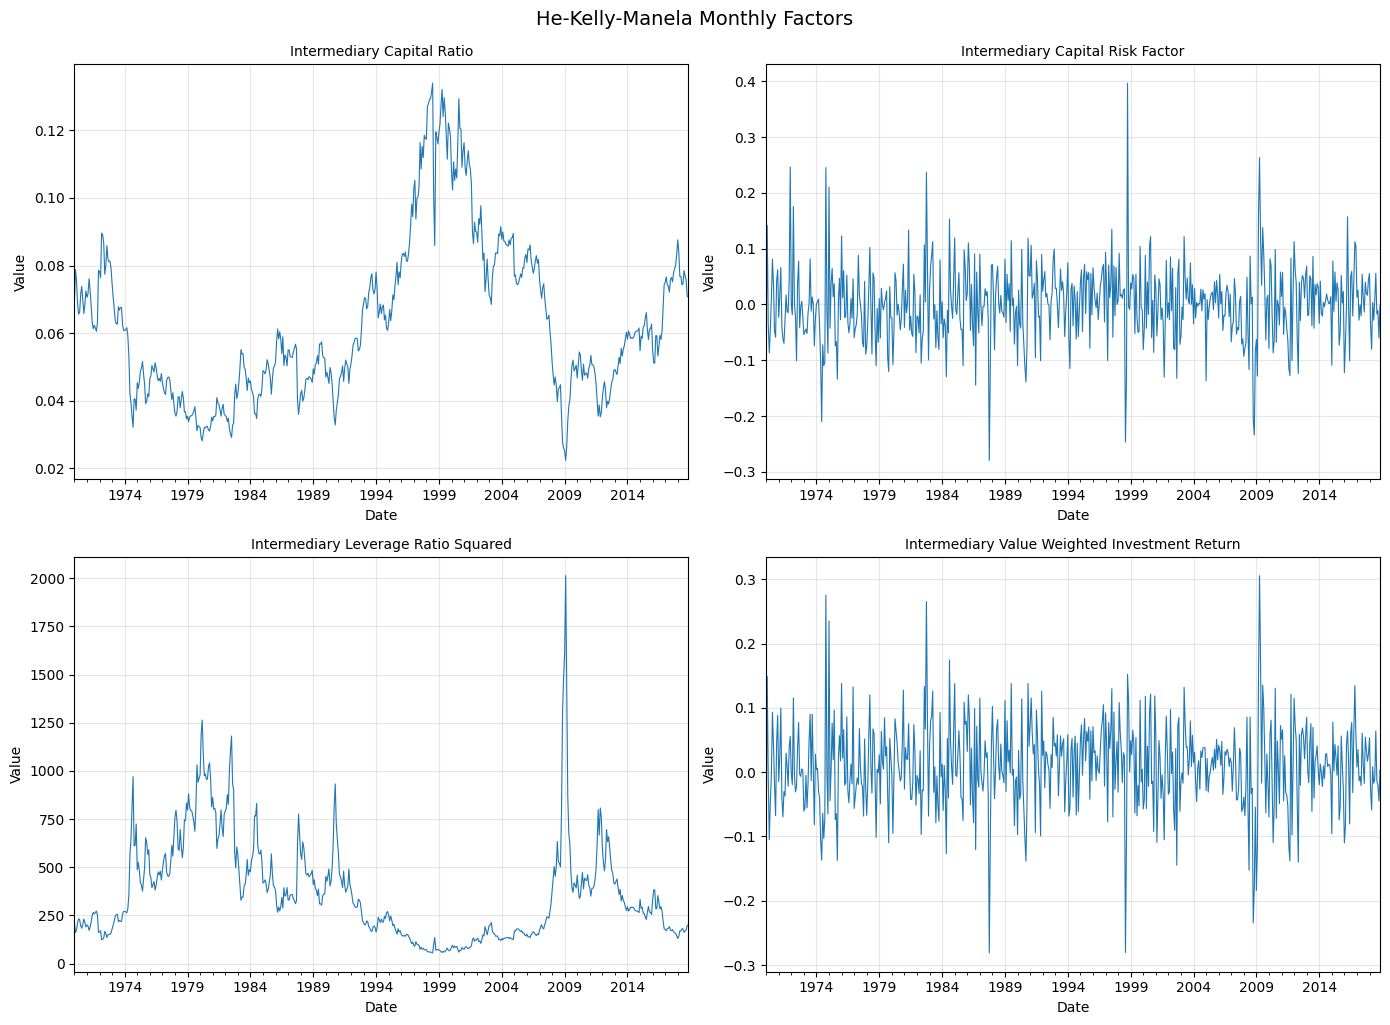

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

factors = monthly_wide.columns.tolist()
for i, factor in enumerate(factors):
    ax = axes[i]
    monthly_wide[factor].plot(ax=ax, linewidth=0.8)
    ax.set_title(factor.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Date')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('He-Kelly-Manela Monthly Factors', y=1.02, fontsize=14)
plt.show()

## Correlation Matrix - Monthly Factors

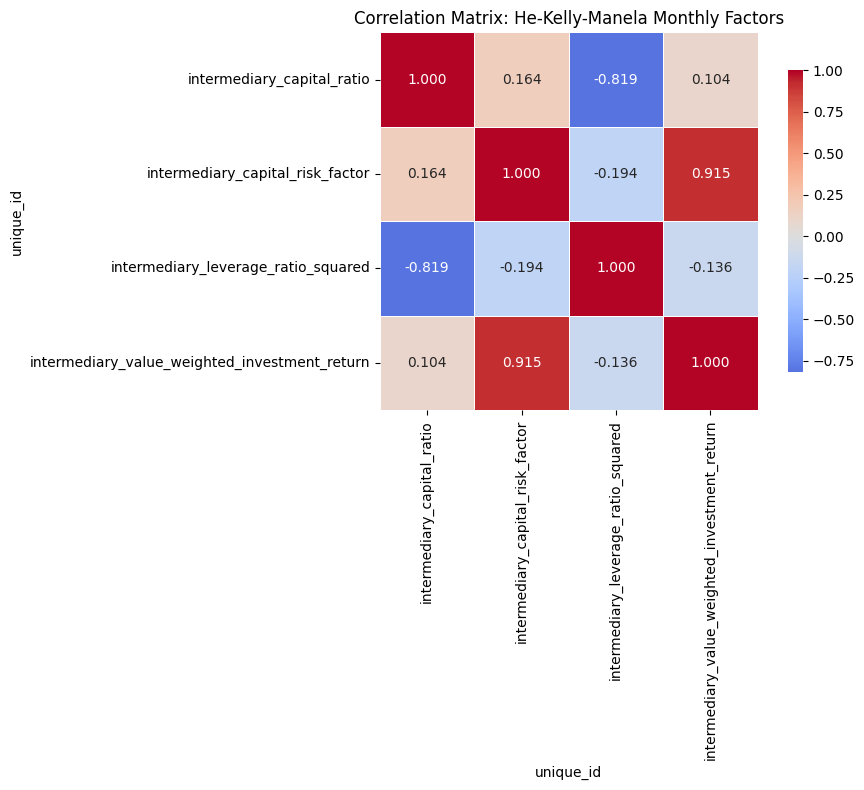

In [7]:
# Calculate correlation matrix
corr_matrix = monthly_wide.corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Matrix: He-Kelly-Manela Monthly Factors', fontsize=12)
plt.tight_layout()
plt.show()

## Summary Statistics - Daily Factors

In [8]:
# Pivot daily data to wide format
daily_wide = daily_df.pivot(index='ds', columns='unique_id', values='y')

# Calculate summary statistics
daily_summary = daily_wide.describe().T
daily_summary['skewness'] = daily_wide.skew()
daily_summary['kurtosis'] = daily_wide.kurtosis()
daily_summary

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
unique_id,,,,,,,,,,
intermediary_capital_ratio,4766.0,0.079561,0.035281,0.014590,0.049814,0.072308,0.106825,0.173551,0.429865,-0.956184
intermediary_capital_risk_factor,4765.0,0.000012,0.017560,-0.160301,-0.006664,0.000244,0.006874,0.180522,0.062697,15.231859
intermediary_leverage_ratio_squared,4766.0,310.194149,377.917039,33.200589,87.630015,191.261908,402.999010,4698.062378,4.156587,26.701841
intermediary_value_weighted_investment_return,4766.0,0.000339,0.016795,-0.118388,-0.006588,0.000254,0.007124,0.193509,0.751259,15.216913


## Data Coverage

Let's examine the date range and data availability for each dataset.

In [9]:
# Monthly data coverage
print("Monthly Factors:")
print(f"  Date range: {monthly_wide.index.min()} to {monthly_wide.index.max()}")
print(f"  Number of observations: {len(monthly_wide)}")
print(f"  Missing values per column:")
print(monthly_wide.isnull().sum())

Monthly Factors:
  Date range: 1970-01-01 00:00:00 to 2018-11-01 00:00:00
  Number of observations: 587
  Missing values per column:
unique_id
intermediary_capital_ratio                       0
intermediary_capital_risk_factor                 0
intermediary_leverage_ratio_squared              0
intermediary_value_weighted_investment_return    0
dtype: int64


In [10]:
# Daily data coverage
print("\nDaily Factors:")
print(f"  Date range: {daily_wide.index.min()} to {daily_wide.index.max()}")
print(f"  Number of observations: {len(daily_wide)}")
print(f"  Missing values per column:")
print(daily_wide.isnull().sum())


Daily Factors:
  Date range: 2000-01-03 00:00:00 to 2018-12-11 00:00:00
  Number of observations: 4766
  Missing values per column:
unique_id
intermediary_capital_ratio                       0
intermediary_capital_risk_factor                 1
intermediary_leverage_ratio_squared              0
intermediary_value_weighted_investment_return    0
dtype: int64


## Distribution Analysis

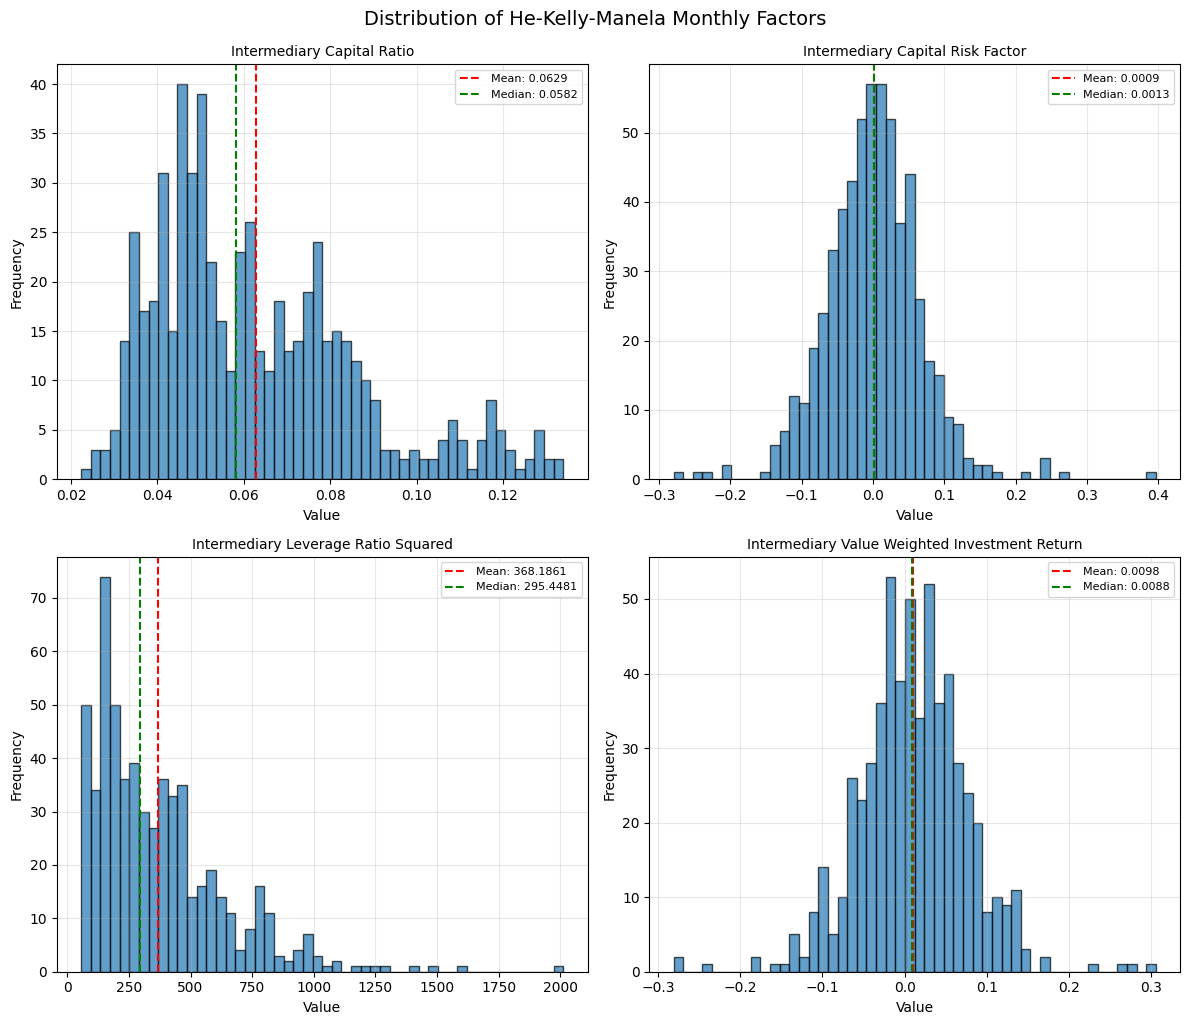

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, factor in enumerate(factors):
    ax = axes[i]
    monthly_wide[factor].hist(ax=ax, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(monthly_wide[factor].mean(), color='red', linestyle='--', label=f'Mean: {monthly_wide[factor].mean():.4f}')
    ax.axvline(monthly_wide[factor].median(), color='green', linestyle='--', label=f'Median: {monthly_wide[factor].median():.4f}')
    ax.set_title(factor.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Distribution of He-Kelly-Manela Monthly Factors', y=1.02, fontsize=14)
plt.show()

## Conclusion

This dataset provides intermediary capital risk factors that can be used for asset pricing studies.
The factors capture the risk-bearing capacity of financial intermediaries and their role in
determining asset prices across multiple asset classes.